# 정상/불량(Machine failure) 이진분류

`ai4i2020.csv`로 `machine_failure`(0=정상, 1=불량)를 맞히는 이진분류 노트북.
**1. 데이터 전처리 -> 2. EDA -> 3. 피처 엔지니어링 -> 4. 모델링(Random Forest/XGBoost/LightGBM x Baseline/Enhanced 비교) -> 5. 결론**
순서로 진행하며, 각 단계는 아래 `#` 대제목으로 구분한다.

## 1. 데이터 로드 및 전처리

`ai4i2020.csv`를 불러와 컬럼명/`Type` 값의 앞뒤 공백을 정리하고, 식별자(`UDI`/`Product ID`)와 타겟과 사실상 동치인 세부 고장 모드 컬럼(`TWF`~`RNF`)을 제거한 뒤 물리 기반 파생변수를 만든다.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('./ai4i2020.csv')
df.columns = [c.strip() for c in df.columns]
df['Type'] = df['Type'].str.strip()  # ' L   ' 같은 앞뒤 공백 제거 (원본 CSV 특성)
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [3]:
df.columns = [c.strip() for c in df.columns]

rename_columns = {
    'Air temperature [K]': 'air_temp',
    'Process temperature [K]': 'process_temp',
    'Rotational speed [rpm]': 'rotational_speed',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'tool_wear',
    'Machine failure': 'machine_failure'
}

df = df.rename(columns=rename_columns).copy()
df

,UDI,Product ID,Type,air_temp,process_temp,rotational_speed,torque,tool_wear,machine_failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [4]:
drop_columns = [
    'UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
]

df = df.drop(columns=drop_columns)

print('데이터 프레임 컬럼:')
print(df.columns.tolist())

데이터 프레임 컬럼:
['Type', 'air_temp', 'process_temp', 'rotational_speed', 'torque', 'tool_wear', 'machine_failure']


In [5]:
df['temp_diff'] = df['process_temp'] - df['air_temp']

df['machanical_power'] = df['torque'] * df['rotational_speed'] * (2*np.pi / 60)

df["tool_stress"] = df["torque"] * df["tool_wear"]

df["temp_ratio"] = df["process_temp"] / df["air_temp"]

df.describe()

,air_temp,process_temp,rotational_speed,torque,tool_wear,machine_failure,temp_diff,machanical_power,tool_stress,temp_ratio
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,10.000630,6279.744953,4314.664550,1.033352
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,1.001094,1067.418295,2826.567692,0.003492
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,7.600000,1148.440610,0.000000,1.025116
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,9.300000,5561.184484,1963.650000,1.030686
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,9.800000,6271.027344,4012.950000,1.032847
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,11.000000,7003.002724,6279.000000,1.036777
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,12.100000,10469.923005,16497.000000,1.040672


## 2. EDA — 정상/불량(`machine_failure`) 이진분류 관점

`Type`(L/M/H)이 아니라 `machine_failure`(0=정상, 1=불량)를 맞히는 이진분류로 목표를 바꿨다.
먼저 클래스 비율과, 정상/불량 사이에 원본 변수·파생변수 분포가 실제로 갈리는지부터 확인한다.

### 2-1. 클래스 불균형 확인

정상: 9661건 / 불량: 339건 (불량률 3.39%)


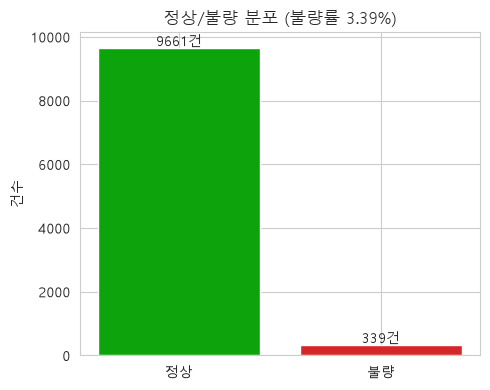

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

STATUS_GOOD = "#0ca30c"
STATUS_BAD = "#d62728"

# 정상/불량 건수 및 비율
status_counts = df["machine_failure"].value_counts().sort_index()
fail_rate = df["machine_failure"].mean() * 100
print(f"정상: {status_counts[0]}건 / 불량: {status_counts[1]}건 (불량률 {fail_rate:.2f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["정상", "불량"], status_counts.values, color=[STATUS_GOOD, STATUS_BAD])
for i, v in enumerate(status_counts.values):
    ax.text(i, v + 50, f"{v}건", ha="center")
ax.set_title(f"정상/불량 분포 (불량률 {fail_rate:.2f}%)")
ax.set_ylabel("건수")
fig.tight_layout()
fig.savefig("../images/modeling2_failure_dist.png", dpi=150, bbox_inches="tight")
plt.show()

**클래스 불균형이 심하다** (`EDA.ipynb`에서 이미 확인한 것과 동일하게 불량이 약 3.4%뿐).
그래서 accuracy만으로는 "전부 정상"이라고만 찍어도 96% 넘게 나오므로, precision/recall/F1/AUC를
같이 봐야 하고, 모델 학습 시 `class_weight="balanced"`로 불량 클래스에 가중치를 줘야 한다.

### 2-2. 변수별 정상/불량 분포 비교

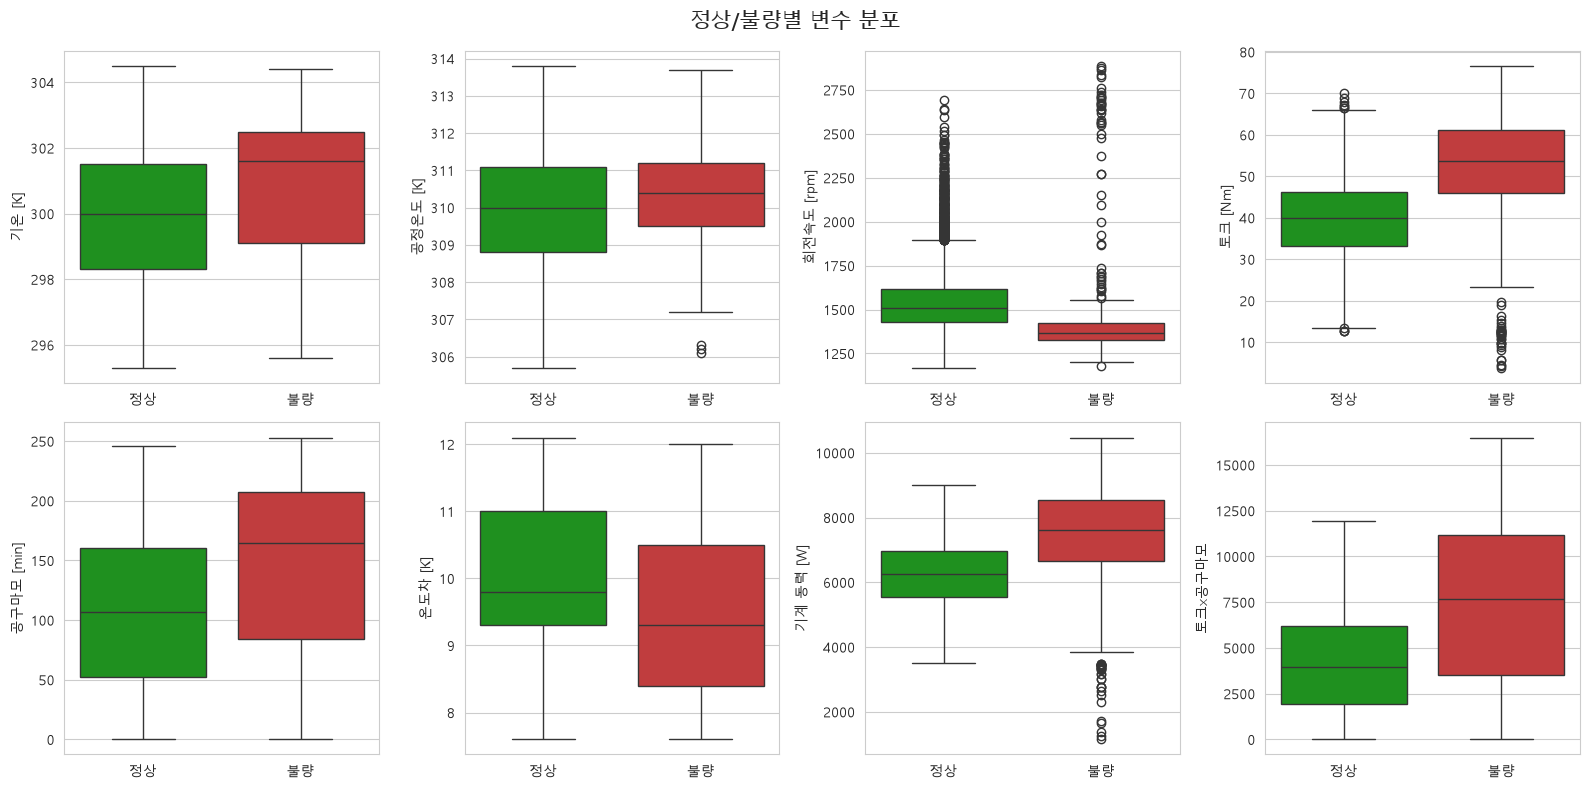

In [7]:
# 원본/파생 변수가 정상·불량 사이에서 실제로 갈리는지 박스플롯으로 확인
box_cols = [
    ("air_temp", "기온 [K]"), ("process_temp", "공정온도 [K]"),
    ("rotational_speed", "회전속도 [rpm]"), ("torque", "토크 [Nm]"),
    ("tool_wear", "공구마모 [min]"), ("temp_diff", "온도차 [K]"),
    ("machanical_power", "기계 동력 [W]"), ("tool_stress", "토크x공구마모"),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (col, label) in zip(axes.ravel(), box_cols):
    sns.boxplot(
        data=df, x="machine_failure", y=col, ax=ax,
        hue="machine_failure", palette={0: STATUS_GOOD, 1: STATUS_BAD}, legend=False,
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["정상", "불량"])
    ax.set_xlabel("")
    ax.set_ylabel(label)

fig.suptitle("정상/불량별 변수 분포", fontsize=15)
fig.tight_layout()
fig.savefig("../images/modeling2_boxplots_by_failure.png", dpi=150, bbox_inches="tight")
plt.show()

박스플롯을 보면 `torque`·`tool_stress`·`machanical_power`는 불량일 때 분포가 훨씬 넓게
퍼져 있다(정상 고장/과부하 양쪽 극단에서 다 발생하기 때문). 반면 `air_temp`/`process_temp` 자체는
정상/불량 차이가 크지 않고, `temp_diff`(공정온도-기온)가 더 잘 갈린다 — 이게 바로 HDF(방열 고장)
판정 기준이 온도 자체가 아니라 온도"차"이기 때문이다. 즉 **원본 변수 하나하나보다, 실제 고장
판정에 쓰이는 조합(차/곱/구간)이 더 좋은 신호**라는 뜻 — 아래 피처 엔지니어링에서 이걸 반영한다.

## 3. 피처 엔지니어링 — "위험구간(zone)" 플래그

AI4I 2020 데이터셋은 각 세부 고장 모드(HDF/PWF/OSF/TWF)가 **원본 변수의 임계값 규칙**으로
결정된다(공식 문서 기준). 원본 컬럼 `TWF`/`HDF`/`PWF`/`OSF`/`RNF`는 이미 위에서 drop했지만,
같은 판정 규칙을 원본 입력 변수(온도/회전속도/토크/공구마모/Type)만으로 다시 계산해서 피처로
추가하는 건 라벨을 직접 쓰는 게 아니므로 데이터 누수가 아니다.

- `hdf_zone`: 온도차 < 8.6K **AND** 회전속도 < 1380rpm (방열 고장 위험구간)
- `pwf_zone`: 동력 < 3500W **OR** 동력 > 9000W (전력 고장 위험구간)
- `osf_zone`: 토크×공구마모가 Type별 임계값(L=11000/M=12000/H=13000) 초과 (과부하 위험구간)
- `high_wear`: 공구마모 > 200분 (TWF가 200~240분 사이에서 랜덤 발생하므로 그 직전 구간)
- `risk_zone_count`: 위 4개를 합산(0~4) — "위험 신호가 몇 개 동시에 켜졌는가"

`osf_zone`은 Type마다 임계값이 다르므로 `Type`을 먼저 안전하게 다뤄야 한다.

### 3-1. 위험구간 플래그 정의 및 생성

In [8]:
# Type별 OSF 임계값 (원본 데이터셋 정의: L=11000, M=12000, H=13000)
osf_threshold = df["Type"].map({"L": 11000, "M": 12000, "H": 13000})

df["hdf_zone"] = ((df["temp_diff"] < 8.6) & (df["rotational_speed"] < 1380)).astype(int)
df["pwf_zone"] = ((df["machanical_power"] < 3500) | (df["machanical_power"] > 9000)).astype(int)
df["osf_zone"] = (df["tool_stress"] > osf_threshold).astype(int)
df["high_wear"] = (df["tool_wear"] > 200).astype(int)
df["risk_zone_count"] = df["hdf_zone"] + df["pwf_zone"] + df["osf_zone"] + df["high_wear"]

df[["hdf_zone", "pwf_zone", "osf_zone", "high_wear", "risk_zone_count"]].sum()

hdf_zone            115
pwf_zone             95
osf_zone             98
high_wear           762
risk_zone_count    1070
dtype: int64

### 3-2. 위험구간 효과 검증

방금 만든 피처가 실제로 신호가 있는지, EDA와 같은 방식(불량률/상관계수)으로 다시 확인한다 — 즉 아래는 원본 데이터가 아니라 **3-1에서 만든 파생변수에 대한 검증**이다.

                    불량률    건수
risk_zone_count              
0                  0.11  9027
1                 27.23   885
2                100.00    79
3                100.00     9


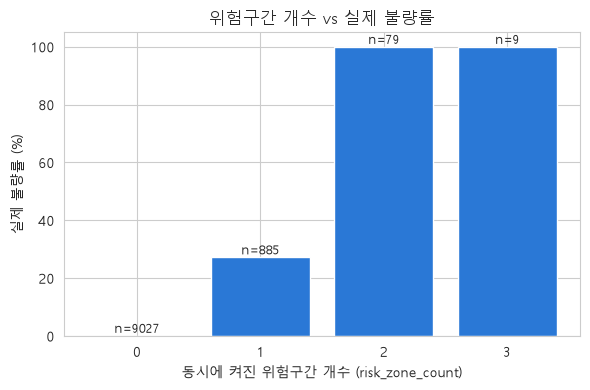

In [9]:
# risk_zone_count별 실제 불량률 — 위험구간이 몇 개 겹치는지가 얼마나 강한 신호인지 확인
risk_summary = df.groupby("risk_zone_count")["machine_failure"].agg(불량률="mean", 건수="count")
risk_summary["불량률"] = (risk_summary["불량률"] * 100).round(2)
print(risk_summary)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(risk_summary.index.astype(str), risk_summary["불량률"], color="#2a78d6")
for bar, cnt in zip(bars, risk_summary["건수"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"n={cnt}", ha="center", fontsize=9)
ax.set_xlabel("동시에 켜진 위험구간 개수 (risk_zone_count)")
ax.set_ylabel("실제 불량률 (%)")
ax.set_title("위험구간 개수 vs 실제 불량률")
fig.tight_layout()
fig.savefig("../images/modeling2_risk_zone_failure_rate.png", dpi=150, bbox_inches="tight")
plt.show()

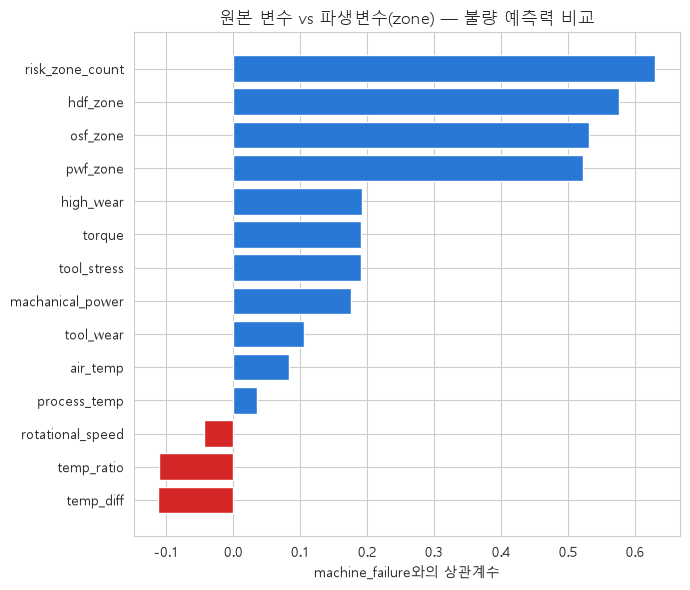

risk_zone_count     0.630259
hdf_zone            0.575800
osf_zone            0.531083
pwf_zone            0.522812
high_wear           0.191957
torque              0.191321
tool_stress         0.190427
machanical_power    0.176039
tool_wear           0.105448
air_temp            0.082556
process_temp        0.035946
rotational_speed   -0.044188
temp_ratio         -0.111347
temp_diff          -0.111676
Name: machine_failure, dtype: float64

In [10]:
# 원본 변수 vs 파생변수(zone 포함) — machine_failure와의 상관계수 비교
corr_cols = [
    "air_temp", "process_temp", "rotational_speed", "torque", "tool_wear",
    "temp_diff", "machanical_power", "tool_stress", "temp_ratio",
    "hdf_zone", "pwf_zone", "osf_zone", "high_wear", "risk_zone_count",
]
corr_with_target = df[corr_cols + ["machine_failure"]].corr()["machine_failure"].drop("machine_failure")
corr_with_target = corr_with_target.sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#d62728" if v < 0 else "#2a78d6" for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors)
ax.set_xlabel("machine_failure와의 상관계수")
ax.set_title("원본 변수 vs 파생변수(zone) — 불량 예측력 비교")
fig.tight_layout()
fig.savefig("../images/modeling2_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

corr_with_target.sort_values(ascending=False)

`risk_zone_count`가 원본 변수를 통틀어 가장 강한 상관관계를 보이고, `hdf_zone`/`osf_zone`/
`pwf_zone`도 각각 원본 `torque`/`tool_wear`보다 한참 앞선다. 즉 "온도가 몇 도냐"보다
"위험구간에 몇 개 걸렸냐"가 불량 여부를 훨씬 잘 설명한다는 뜻이다.

## 4. 모델링 — 모델 3종(Random Forest/XGBoost/LightGBM) x Baseline(원본만)/Enhanced(zone 피처 추가) 비교

같은 두 피처셋(Baseline/Enhanced)에 트리 기반 모델 3종을 각각 학습시켜, **"zone 피처 추가 효과가 모델 종류와 무관하게 재현되는지"**까지 확인한다. 타겟은 `machine_failure`(0/1)이고, 클래스 불균형(불량 3.39%) 때문에 각 모델에 맞는 방식으로 불량 클래스 가중치를 준다(RF/LightGBM은 `class_weight="balanced"`, XGBoost는 `scale_pos_weight`).

### 4-1. 모델 학습 및 평가 (Random Forest / XGBoost / LightGBM)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

RANDOM_STATE = 42

df_model = pd.get_dummies(df, columns=["Type"], drop_first=True)

baseline_cols = [
    "air_temp", "process_temp", "rotational_speed", "torque", "tool_wear",
    "Type_L", "Type_M",
]
enhanced_cols = baseline_cols + [
    "temp_diff", "machanical_power", "tool_stress",
    "hdf_zone", "pwf_zone", "osf_zone", "high_wear", "risk_zone_count",
]
feature_sets = {"Baseline": baseline_cols, "Enhanced": enhanced_cols}
y = df_model["machine_failure"]

eval_results = {}
confusions = {}

for feat_name, cols in feature_sets.items():
    X = df_model[cols]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    # XGBoost는 class_weight 인자가 없어 scale_pos_weight(음성/양성 비율)로 불균형을 보정한다
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300, random_state=RANDOM_STATE,
            eval_metric="logloss", scale_pos_weight=scale_pos_weight,
        ),
        "LightGBM": LGBMClassifier(
            n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, verbose=-1
        ),
    }

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        key = f"{model_name} ({feat_name})"
        eval_results[key] = {
            "모델": model_name,
            "피처셋": feat_name,
            "정확도": accuracy_score(y_test, y_pred),
            "정밀도": precision_score(y_test, y_pred),
            "재현율": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred),
            "AUC": roc_auc_score(y_test, y_proba),
        }
        confusions[key] = confusion_matrix(y_test, y_pred)
        print(f"--- {key} ---")
        print(classification_report(y_test, y_pred, target_names=["정상", "불량"]))

results_df = pd.DataFrame(eval_results).T
metric_cols = ["정확도", "정밀도", "재현율", "F1-score", "AUC"]
results_df[metric_cols] = results_df[metric_cols].astype(float)
results_df[["모델", "피처셋"] + metric_cols].round(3)

--- Random Forest (Baseline) ---
              precision    recall  f1-score   support

          정상       0.99      0.99      0.99      1932
          불량       0.75      0.71      0.73        68

    accuracy                           0.98      2000
   macro avg       0.87      0.85      0.86      2000
weighted avg       0.98      0.98      0.98      2000

--- XGBoost (Baseline) ---
              precision    recall  f1-score   support

          정상       0.99      0.99      0.99      1932
          불량       0.76      0.75      0.76        68

    accuracy                           0.98      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.98      0.98      0.98      2000

--- LightGBM (Baseline) ---
              precision    recall  f1-score   support

          정상       0.99      0.99      0.99      1932
          불량       0.84      0.76      0.80        68

    accuracy                           0.99      2000
   macro avg       0.92      0.88      0

,모델,피처셋,정확도,정밀도,재현율,F1-score,AUC
Random Forest (Baseline),Random Forest,Baseline,0.982,0.750,0.706,0.727,0.970
XGBoost (Baseline),XGBoost,Baseline,0.984,0.761,0.750,0.756,0.970
LightGBM (Baseline),LightGBM,Baseline,0.987,0.839,0.765,0.800,0.971
Random Forest (Enhanced),Random Forest,Enhanced,0.994,1.000,0.838,0.912,0.973
XGBoost (Enhanced),XGBoost,Enhanced,0.992,0.934,0.838,0.884,0.973
LightGBM (Enhanced),LightGBM,Enhanced,0.994,0.966,0.838,0.898,0.974


### 4-2. 지표 비교 그래프 — 모델 3종 x Baseline/Enhanced

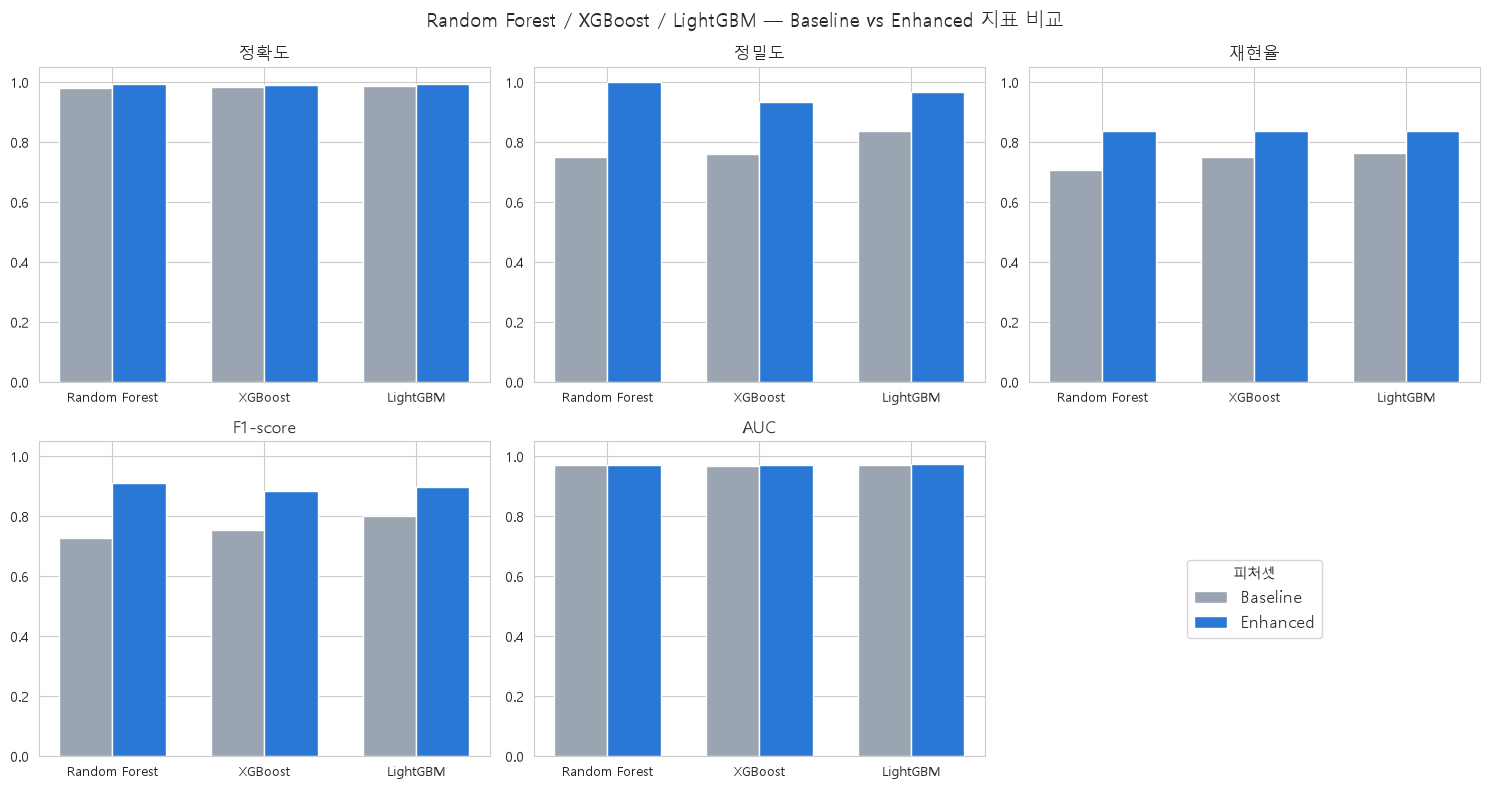

In [12]:
# 모델 3종 x Baseline/Enhanced 지표 비교 (지표별 서브플롯, 모델은 x축, 피처셋은 막대 그룹)
model_order = ["Random Forest", "XGBoost", "LightGBM"]
feat_order = ["Baseline", "Enhanced"]
feat_colors = {"Baseline": "#9aa5b1", "Enhanced": "#2a78d6"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, metric in zip(axes.ravel(), metric_cols):
    x = np.arange(len(model_order))
    width = 0.35
    for i, feat in enumerate(feat_order):
        vals = [
            results_df[(results_df["모델"] == m) & (results_df["피처셋"] == feat)][metric].iloc[0]
            for m in model_order
        ]
        ax.bar(x + (i - 0.5) * width, vals, width, label=feat, color=feat_colors[feat])
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, fontsize=9)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)

axes.ravel()[-1].axis("off")
handles, labels = axes[0, 0].get_legend_handles_labels()
axes.ravel()[-1].legend(handles, labels, loc="center", fontsize=12, title="피처셋")

fig.suptitle("Random Forest / XGBoost / LightGBM — Baseline vs Enhanced 지표 비교", fontsize=14)
fig.tight_layout()
fig.savefig("../images/modeling2_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 4-3. 혼동행렬 비교 — 모델 3종 x Baseline/Enhanced

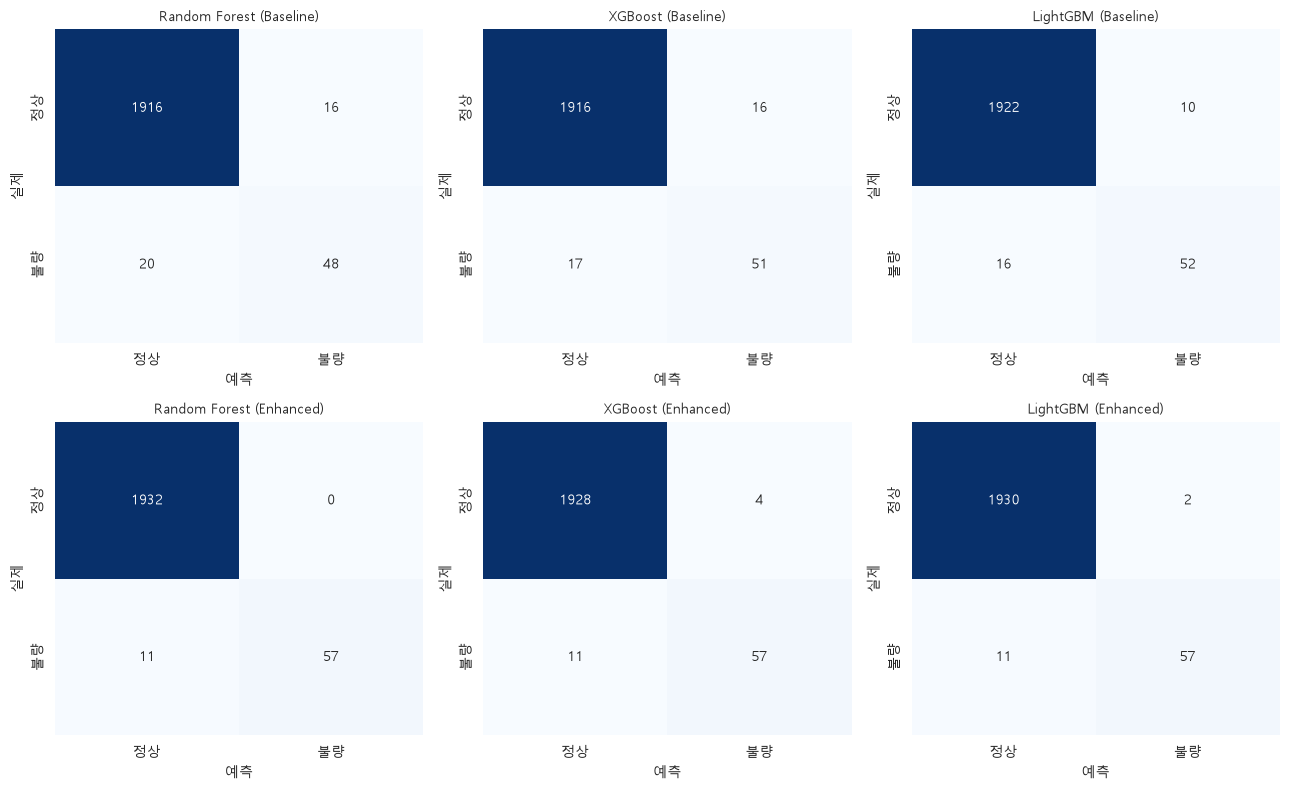

In [13]:
# 혼동행렬 비교 (2행: Baseline/Enhanced, 3열: Random Forest/XGBoost/LightGBM)
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for row, feat in enumerate(feat_order):
    for col, model_name in enumerate(model_order):
        ax = axes[row, col]
        key = f"{model_name} ({feat})"
        sns.heatmap(
            confusions[key], annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
            xticklabels=["정상", "불량"], yticklabels=["정상", "불량"],
        )
        ax.set_title(f"{model_name} ({feat})", fontsize=10)
        ax.set_xlabel("예측")
        ax.set_ylabel("실제")

fig.tight_layout()
fig.savefig("../images/modeling2_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. 결론

모델 3종(Random Forest/XGBoost/LightGBM) x 피처셋 2종(Baseline/Enhanced) 총 6가지 조합의
불량(1) 클래스 기준 지표:

| 모델 | 피처셋 | 정확도 | 정밀도 | 재현율 | F1-score | AUC |
| --- | --- | --- | --- | --- | --- | --- |
| Random Forest | Baseline | 0.982 | 0.750 | 0.706 | 0.727 | 0.970 |
| XGBoost | Baseline | 0.984 | 0.761 | 0.750 | 0.756 | 0.970 |
| LightGBM | Baseline | 0.987 | 0.839 | 0.765 | **0.800** | 0.971 |
| Random Forest | Enhanced | 0.994 | 1.000 | 0.838 | **0.912** | 0.973 |
| XGBoost | Enhanced | 0.992 | 0.934 | 0.838 | 0.884 | 0.973 |
| LightGBM | Enhanced | 0.994 | 0.966 | 0.838 | 0.898 | 0.974 |

- **zone 피처(Enhanced) 추가 효과는 모델 종류와 무관하게 재현된다** — 3개 모델 전부 F1이
  올랐다(RF +0.185, XGBoost +0.128, LightGBM +0.098). 즉 지난 결론(RF 단일 모델 기준)이
  우연이 아니라 트리 기반 모델 계열에서 일관되게 나타나는 효과라는 게 확인됐다.
- **Baseline만 비교하면 LightGBM(F1 0.800)이 Random Forest(0.727)·XGBoost(0.756)보다
  뚜렷하게 앞선다** — 그래디언트 부스팅 계열(LightGBM/XGBoost)이 원본 변수만으로도 RF보다
  더 잘 그 조합 규칙(온도차×회전속도 AND 조건, Type별 임계값 등)을 스스로 찾아낸다는 뜻이다.
  반대로 말하면 **zone 피처는 이 조합 규칙을 스스로 찾기 상대적으로 약한 Random Forest에서
  더 크게 도움이 됐다**(개선폭이 가장 큼).
- **Enhanced에서는 Random Forest(F1 0.912)가 오히려 셋 중 가장 좋다** — zone 피처가
  이미 조합 규칙을 다 계산해서 넣어준 상태라, 모델이 그 규칙을 스스로 재발견할 필요가 없어져서
  Random Forest·XGBoost·LightGBM 사이의 차이가 좁혀지고(F1 0.884~0.912), 단순한 모델(RF)도
  충분히 따라잡는다.
- **재현율(0.838)이 Enhanced 3개 모델 전부 정확히 같다** — `risk_zone_count>=2`일 때 불량률이
  100%인 매우 강한 규칙이 세 모델 모두에게 똑같은 "확실한 불량" 샘플들을 잡아내게 만들기 때문으로
  해석된다. 반면 정밀도는 RF(1.000) > LightGBM(0.966) > XGBoost(0.934) 순으로 갈렸는데, 정상을
  불량으로 오탐하는 경계선 샘플을 처리하는 방식이 모델마다 달랐다는 뜻이다.
- **AUC는 6개 조합 전부 0.970~0.974로 사실상 차이가 없다** — Baseline 단계에서 이미
  `torque`/`tool_wear`만으로도 순위를 잘 매기고 있어서, zone 피처나 모델 종류가 "순위를 매기는
  능력"보다는 "임계값 근처에서 정확히 가르는 능력(precision/recall/F1)"에 주로 기여했다는 이전
  결론이 모델 3종에서도 그대로 재확인된다.
- 정리 문서: [`docs/modeling2_binary_eda.md`](../docs/modeling2_binary_eda.md)
- 실행: 저장소 루트에서 `jupyter nbconvert --to notebook --execute --inplace src/modeling2.ipynb`
  (`lightgbm`/`xgboost` 설치 필요: `./venv/Scripts/python -m pip install lightgbm xgboost`)